In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score


In [2]:
data = pd.read_csv("Admission_Predict.csv")

In [3]:
data

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


In [4]:
data.shape

(400, 9)

In [5]:
data = data.drop("Serial No.", axis = 1)
#clean the dataset by removing unnecessary or irrelevant columns

In [6]:
# Data Wrangling
print("\nNull Values:\n", data.isnull().sum())


Null Values:
 GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


In [7]:
# Remove rows with null values
data_cleaned = data
# Show the cleaned data
print("\nData after removing null values:\n", data_cleaned.head())


Data after removing null values:
    GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  Research  \
0        337          118                  4  4.5   4.5  9.65         1   
1        324          107                  4  4.0   4.5  8.87         1   
2        316          104                  3  3.0   3.5  8.00         1   
3        322          110                  3  3.5   2.5  8.67         1   
4        314          103                  2  2.0   3.0  8.21         0   

   Chance of Admit   
0              0.92  
1              0.76  
2              0.72  
3              0.80  
4              0.65  


In [8]:
data.describe()


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


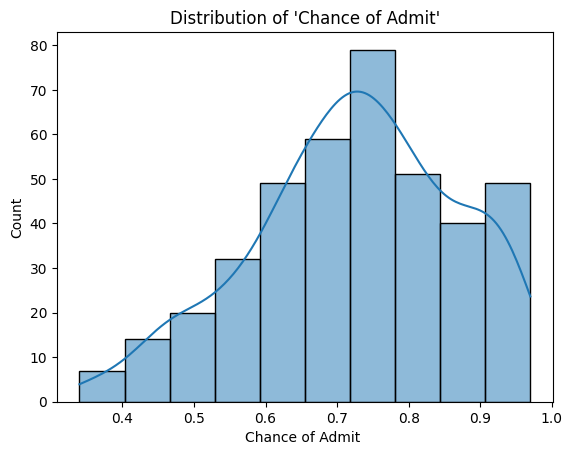

In [9]:
sns.histplot(data["Chance of Admit "], bins=10, kde=True)
plt.title("Distribution of 'Chance of Admit'")
plt.show()

In [10]:
class_counts = data['Chance of Admit '].value_counts()
print(class_counts)

# Calculate balance ratio
balance_ratio = class_counts.min() / class_counts.max()
if balance_ratio > 0.5:
    print("The data is balanced.")
else:
    print("The data is unbalanced.")

Chance of Admit 
0.64    17
0.71    16
0.72    15
0.73    13
0.94    12
0.79    12
0.76    12
0.70    12
0.78    12
0.74    11
0.80    11
0.68    10
0.93     9
0.84     9
0.89     9
0.65     9
0.62     9
0.82     8
0.86     8
0.75     8
0.90     8
0.57     8
0.81     8
0.77     8
0.91     7
0.69     7
0.96     7
0.66     7
0.61     7
0.67     7
0.85     6
0.63     6
0.56     6
0.92     6
0.58     5
0.46     5
0.87     5
0.54     5
0.52     5
0.47     5
0.59     4
0.49     4
0.97     4
0.88     4
0.95     4
0.53     3
0.48     3
0.44     3
0.42     3
0.83     3
0.38     2
0.34     2
0.36     2
0.45     2
0.50     2
0.43     1
0.51     1
0.55     1
0.60     1
0.39     1
Name: count, dtype: int64
The data is unbalanced.


In [11]:
threshold_chance_of_admit = data['Chance of Admit '].quantile(0.75)
print(f"75th percentile threshold for 'Chance of Admit ': {threshold_chance_of_admit}")

# Define the function to label encode based on the specific threshold
def LabelEnc(x):
    if x >= threshold_chance_of_admit:
        return 1
    else:
        return 0
# Apply the function to the 'Chance of Admit ' column by Akshit
data["Chance of Admit "] = data["Chance of Admit "].apply(LabelEnc)

75th percentile threshold for 'Chance of Admit ': 0.83


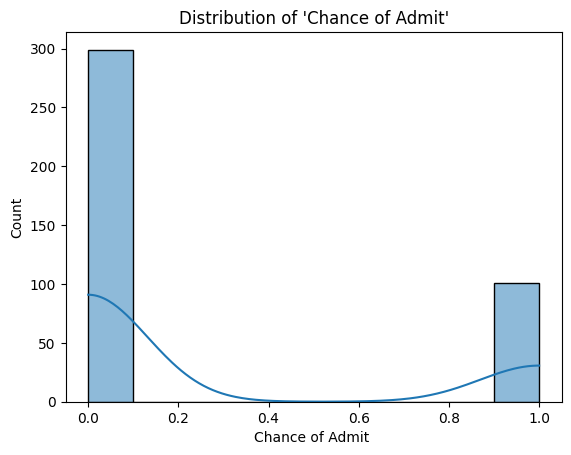

In [12]:
sns.histplot(data["Chance of Admit "], bins=10, kde=True)
plt.title("Distribution of 'Chance of Admit'")
plt.show()

In [13]:
class_counts = data['Chance of Admit '].value_counts()
print(class_counts)

Chance of Admit 
0    299
1    101
Name: count, dtype: int64


In [14]:
data

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,0
2,316,104,3,3.0,3.5,8.00,1,0
3,322,110,3,3.5,2.5,8.67,1,0
4,314,103,2,2.0,3.0,8.21,0,0
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,0
396,325,107,3,3.0,3.5,9.11,1,1
397,330,116,4,5.0,4.5,9.45,1,1
398,312,103,3,3.5,4.0,8.78,0,0


In [15]:
y = data["Chance of Admit "] # 'y' represents the target variable
x = data[['GRE Score','TOEFL Score']]
#includes all the columns based on  GRE score and toefel score 

In [16]:
# Standardizing the features for Apply Data pre-processing 
X = data.drop('Chance of Admit ', axis=1)  # Drop the target variable
#Removes the target variable "Chance of Admit" from the DataFrame, leaving only features for scaling.
scaler = StandardScaler()
#Creates a StandardScaler object to standardize features by removing the mean and scaling to unit variance.
X_scaled = scaler.fit_transform(X)
#Fits the scaler to the feature data and then transforms the data, standardizing it.
# Converting back to DataFrame for easier readability (optional)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [17]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a model (Decision Tree)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

Accuracy: 0.9333333333333333
Precision: 0.896551724137931
Recall: 0.8387096774193549


In [18]:
# Define different test sizes to try (e.g., 10%, 20%, 30%)
test_size_options = [0.1, 0.2, 0.3, 0.4]
#model = DecisionTreeClassifier(random_state=42)
gini_classifier = DecisionTreeClassifier(criterion="gini",random_state=42) #use of information gain is there 
# Empty list to store accuracy scores for different test sizes
accuracy_scores = []

# Loop through each test size and evaluate the model
for test_size in test_size_options:
    # Split the data using the current test size
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)
    
    # Train the model
    gini_classifier.fit(X_train, y_train)
    
    # Make predictions and evaluate accuracy
    y_pred = gini_classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Store the accuracy
    accuracy_scores.append((test_size, accuracy))

# Output the results for each test size
for size, acc in accuracy_scores:
    print(f"Test size: {size}, Accuracy: {acc}")

best_test_size, best_accuracy = max(accuracy_scores, key=lambda x: x[1])
print(f"Best test size: {best_test_size}, Maximum accuracy: {best_accuracy}")
optimal_test_size = best_test_size

Test size: 0.1, Accuracy: 1.0
Test size: 0.2, Accuracy: 0.9125
Test size: 0.3, Accuracy: 0.9333333333333333
Test size: 0.4, Accuracy: 0.90625
Best test size: 0.1, Maximum accuracy: 1.0


In [19]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = optimal_test_size, random_state=42)

In [20]:
entropy_classifier = DecisionTreeClassifier(criterion="entropy")

In [21]:
gini_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [22]:
entropy_classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [23]:
# Predicting the target values for the training set using the Gini-based decision tree
pred_train_gini = gini_classifier.predict(X_train)

# Predicting the target values for the test set using the Gini-based decision tree
pred_test_gini = gini_classifier.predict(X_test)

# Predicting the target values for the training set using the Entropy-based decision tree
pred_train_entropy = entropy_classifier.predict(X_train)

# Predicting the target values for the test set using the Entropy-based decision tree
pred_test_entropy = entropy_classifier.predict(X_test)


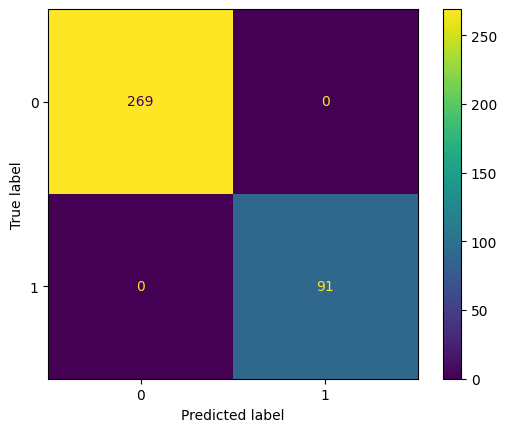

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00       269\n           1       1.00      1.00      1.00        91\n\n    accuracy                           1.00       360\n   macro avg       1.00      1.00      1.00       360\nweighted avg       1.00      1.00      1.00       360\n'

In [24]:
ConfusionMatrixDisplay.from_predictions(y_train, pred_train_gini)  # Displays a confusion matrix for predictions vs actual labels
plt.show()  # Shows the plot of the confusion matrix
classification_report(y_train, pred_train_gini)  # Prints a detailed classification report including precision, recall, and F1 score
# By Akshit

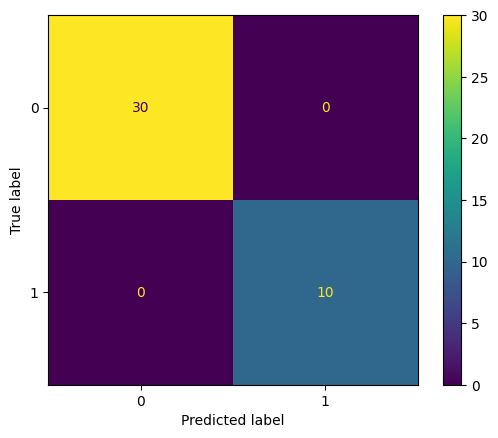

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        30\n           1       1.00      1.00      1.00        10\n\n    accuracy                           1.00        40\n   macro avg       1.00      1.00      1.00        40\nweighted avg       1.00      1.00      1.00        40\n'

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_test_gini)  # Displays confusion matrix for test data predictions
plt.show()  # Shows the plot of the confusion matrix
classification_report(y_test, pred_test_gini)  # Prints classification metrics for test data predictions
# By Akshit

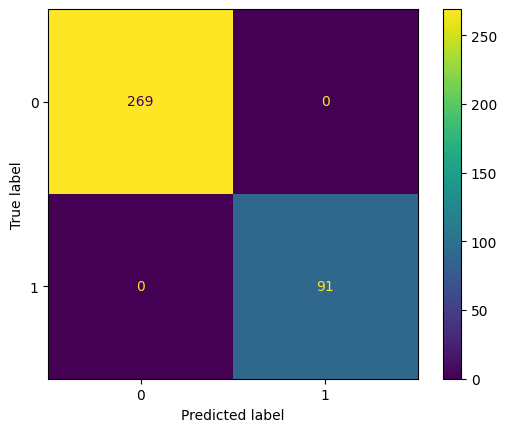

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00       269\n           1       1.00      1.00      1.00        91\n\n    accuracy                           1.00       360\n   macro avg       1.00      1.00      1.00       360\nweighted avg       1.00      1.00      1.00       360\n'

In [26]:
ConfusionMatrixDisplay.from_predictions(y_train, pred_train_entropy)  # Shows confusion matrix for training data predictions using entropy
plt.show()  # Displays the confusion matrix plot
classification_report(y_train, pred_train_entropy)  # Outputs classification metrics for training data predictions


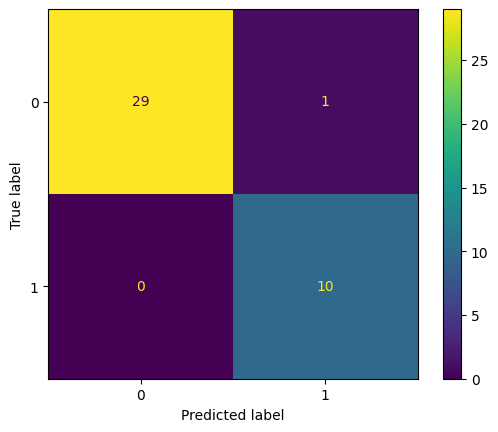

'              precision    recall  f1-score   support\n\n           0       1.00      0.97      0.98        30\n           1       0.91      1.00      0.95        10\n\n    accuracy                           0.97        40\n   macro avg       0.95      0.98      0.97        40\nweighted avg       0.98      0.97      0.98        40\n'

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_test_entropy)  # Shows confusion matrix for test data predictions using entropy
plt.show()  # Displays the confusion matrix plot
classification_report(y_test, pred_test_entropy)  # Outputs classification metrics for test data predictions

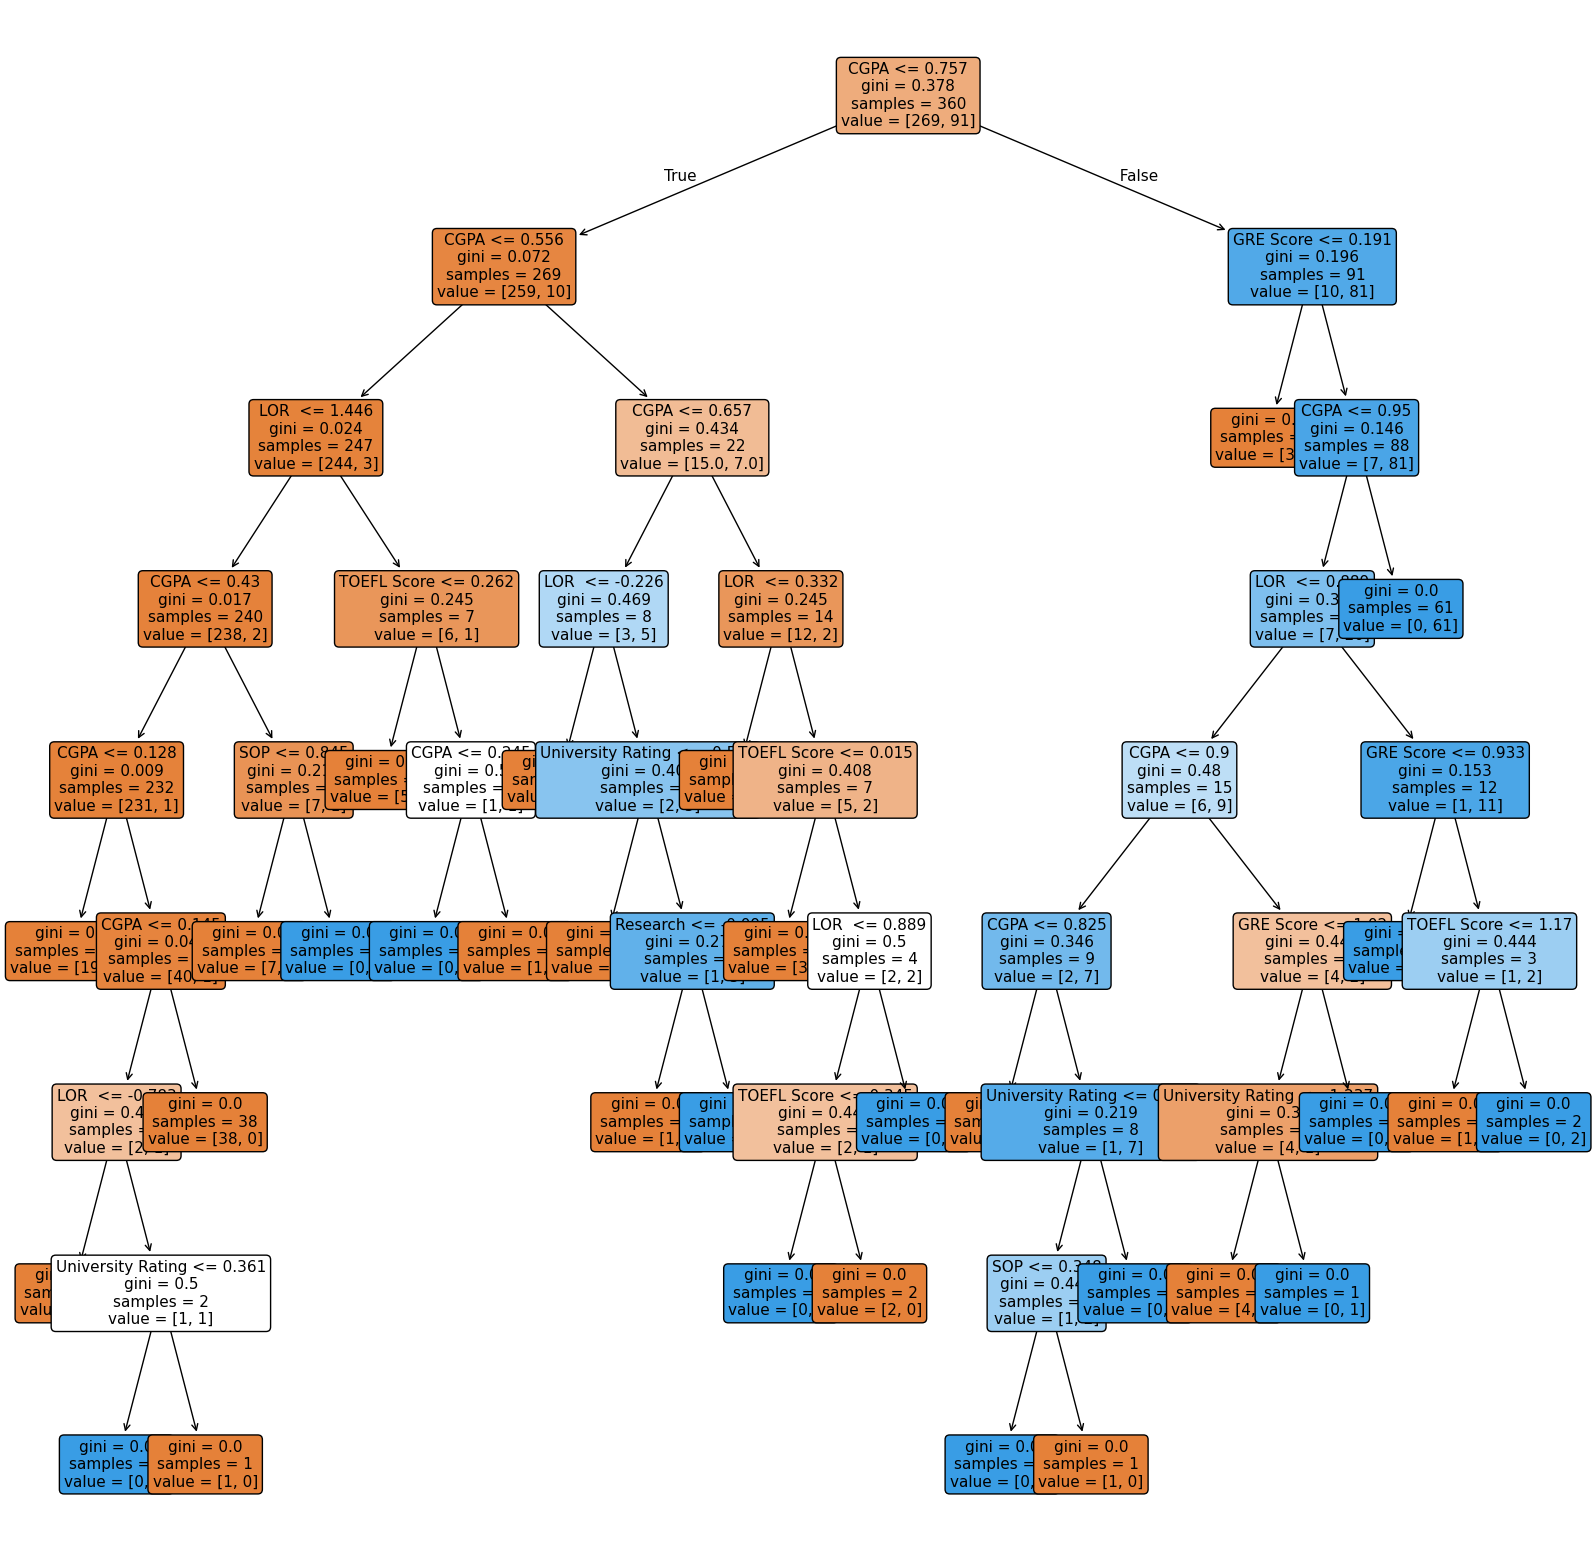

In [28]:
plt.figure(figsize=(20, 20))  # Sets the figure size for the plot

plot_tree(gini_classifier, 
          feature_names=X.columns,  # Labels nodes with feature names
          filled=True,                    # Colors nodes based on class
          rounded=True,                   # Rounds node edges for better appearance
          fontsize=11)                    # Sets font size for text in the plot

plt.show()  # Displays the decision tree plot


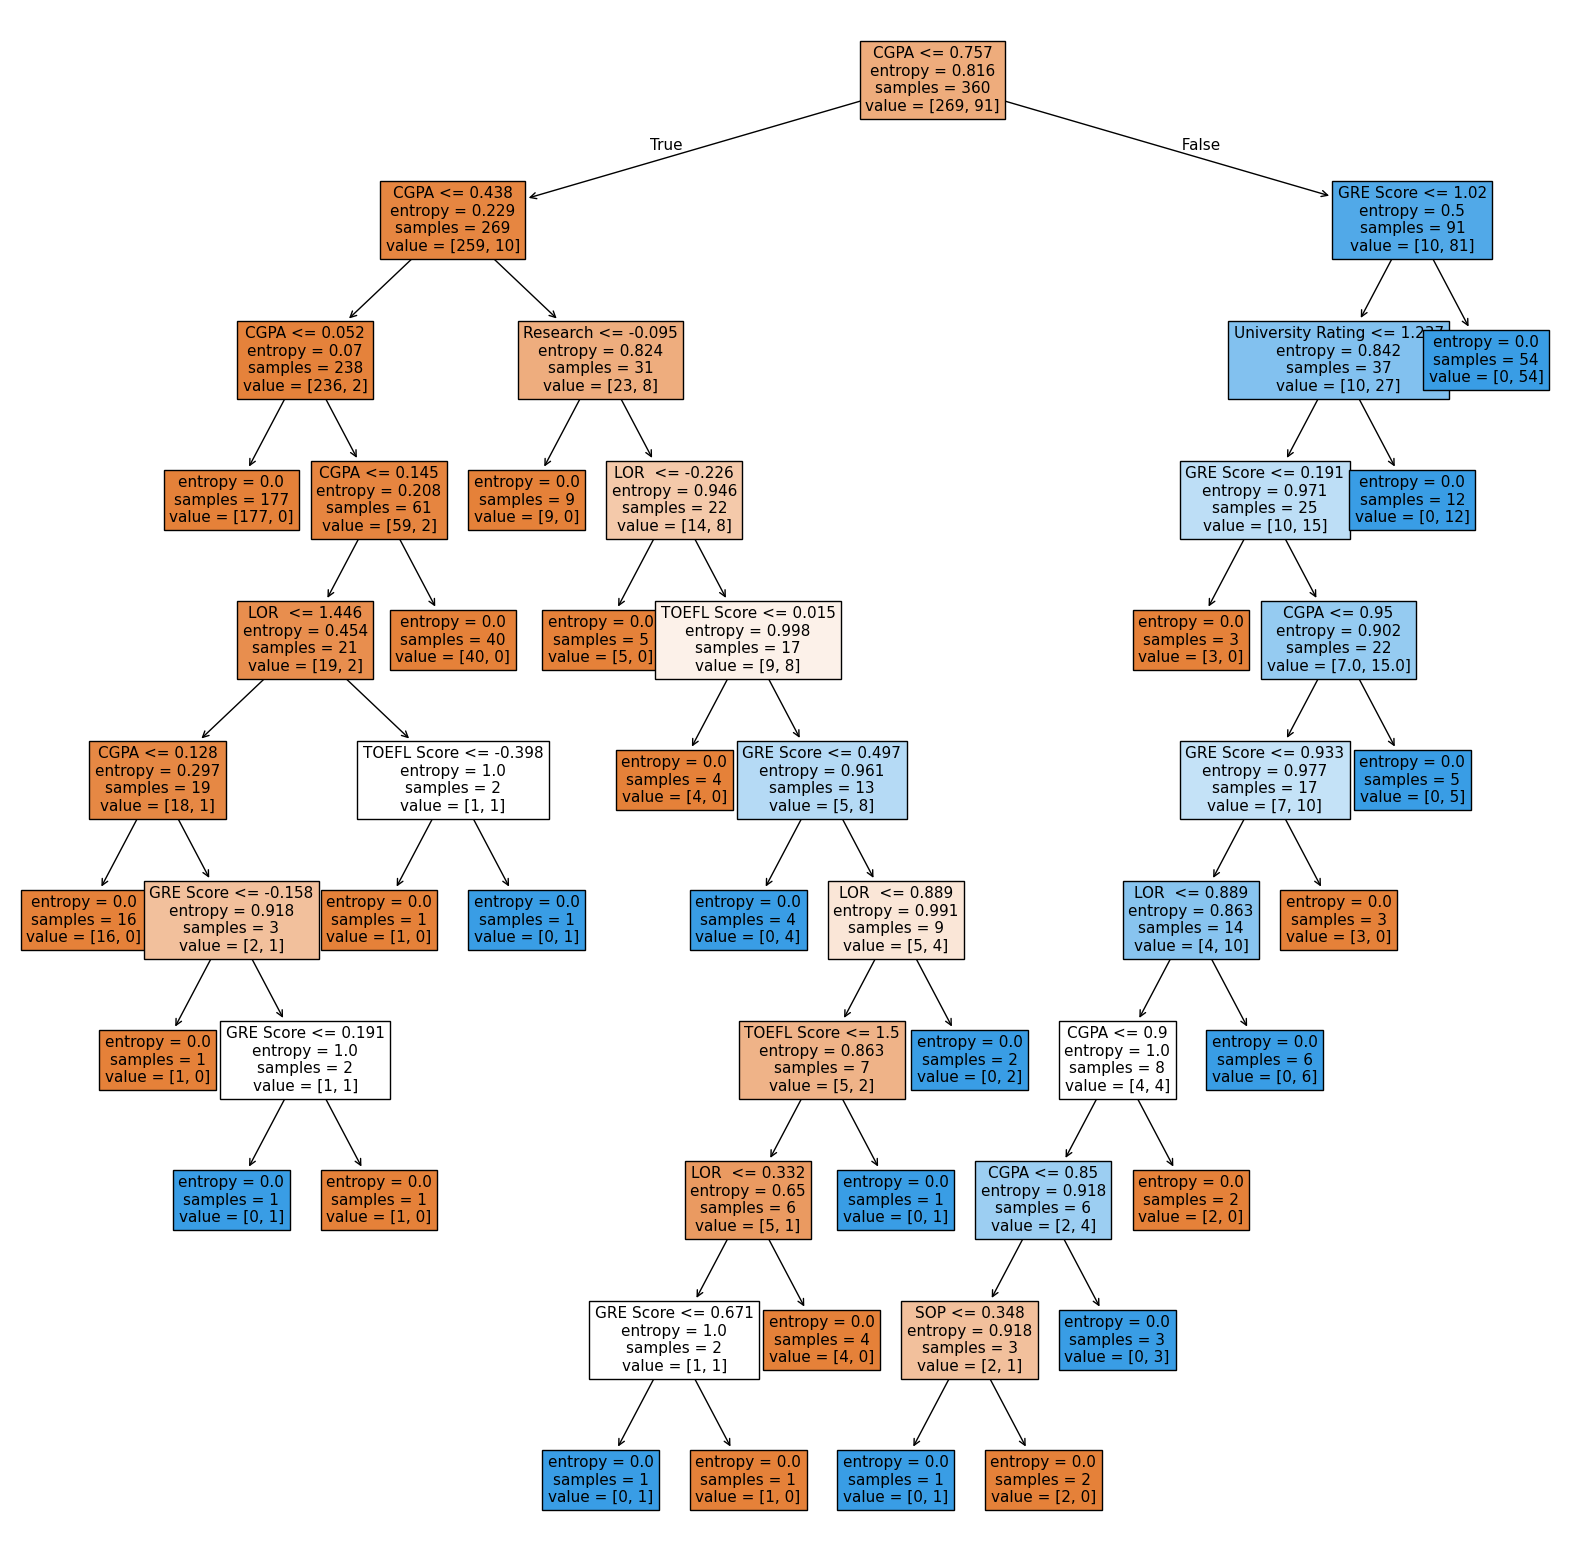

In [29]:
plt.figure(figsize=(20, 20))  # Sets the figure size to 20x20 inches
plot_tree(entropy_classifier, 
          feature_names=X.columns,  # Labels nodes with feature names
          filled=True,                    # Colors nodes based on class
          fontsize=11)                    # Sets font size for text in the plot
plt.show()  # Displays the plot


In [30]:
thank_you = '\u0927\u0928\u094D\u092F\u093E\u0935\u093E\u0928'
print(thank_you)


धन्यावान
